### installation

uv add langgraph

uv add langchain[google-genai]

In [3]:
import os 
from dotenv import load_dotenv

load_dotenv()
api_key= os.getenv("GEMINI_API_KEY")

## **Creating Chatbot using LangGraph**

In [5]:
from langchain.chat_models import init_chat_model

llm = init_chat_model(model="gemini-2.5-flash-lite",api_key=api_key,model_provider="google_genai")

llm.invoke("write a poem on hello world").content

"A whisper soft, a gentle start,\nA phrase that echoes in the heart.\nNo grand design, no complex plea,\nJust simple words for all to see.\n\n**Hello, World!** the message rings,\nOn silent keyboards, feathered wings.\nA digital dawn, a brand new day,\nWhere thoughts and feelings find their way.\n\nFrom lines of code, a spark ignites,\nA tiny beacon, burning bright.\nA promise held, a path to tread,\nWhere possibilities lie ahead.\n\nIt's not just text, it's more than speech,\nA bridge that reaches, within our reach.\nA greeting sent across the void,\nA world of wonder, to be enjoyed.\n\nSo let the echo softly grow,\nFrom every screen, a vibrant glow.\n**Hello, World!** a simple art,\nThe first few words, to play our part."

In [9]:
from typing import Annotated, TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list,add_messages]


def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # resposne store state
    return {"messages": [response]}



In [10]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node',chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

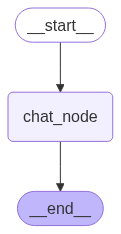

In [11]:
chatbot

In [ ]:
from langchain_core.messages import BaseMessage, HumanMessage

initia_state = {
    'messages' : [HumanMessage(content='What is the capital of india')]
}
 
chatbot.invoke(initia_state)['messages'][-1].content

'The capital of India is **New Delhi**.'

In [21]:
while True:

    user_message = input("Type here: ")
    print('User: ',user_message)

    if user_message.strip().lower() in ['exit','bye','q','quit']:break
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]})
    print('AI: ', response['messages'][-1].content)

User:  hi my name is talha, how are you?
AI:  Hi Talha! I'm doing well, thank you for asking. As a large language model, I don't experience feelings in the same way humans do, but I'm functioning optimally and ready to assist you.

How are you doing today? Is there anything I can help you with?
User:  can you tell me my name?
AI:  I do not have access to your personal information, including your name. I am a large language model, trained by Google.
User:  what was my previous message?
AI:  I am a large language model, trained by Google. I do not have access to previous conversations.
User:  bye


### Keeping memory

In [24]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node',chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpointer)

In [28]:
thread_id = '1'

while True:

    user_message = input("Type here: ")
    print('User: ',user_message)

    if user_message.strip().lower() in ['exit','bye','q','quit']:break

    config = {'configurable': {'thread_id':thread_id}}
    
    response = chatbot.invoke({'messages': [HumanMessage(content=user_message)]}, config=config)
    print('AI: ', response['messages'][-1].content)

User:  can you add 10 to 100
AI:  Yes, 100 + 10 = **110**.
User:  can you now muliply the result with 5
AI:  Of course!

110 multiplied by 5 is **550**.
User:  bye


In [29]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi my name is talha', additional_kwargs={}, response_metadata={}, id='cfafcfb0-25d9-4360-8c8d-97bfa2caa6a4'), AIMessage(content="Hi Talha! It's nice to meet you. How can I help you today?", additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--10423c18-4f2e-430a-bd83-a86ef6bc2f84-0', usage_metadata={'input_tokens': 7, 'output_tokens': 19, 'total_tokens': 26, 'input_token_details': {'cache_read': 0}}), HumanMessage(content='can you tell me my name?', additional_kwargs={}, response_metadata={}, id='7e32e334-8db4-424b-a5f8-4fc35320ee0f'), AIMessage(content='Yes, your name is **Talha**.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--6771016